# Experiment 1 — RNN with Attention for Sentiment Classification

## Aim
To implement and evaluate a PyTorch sentiment classifier with the pipeline **text → tokenization → embedding → bidirectional LSTM → additive attention → fully connected classifier → sentiment**.

## Objectives

1. Build a vocabulary and numericalize raw reviews without a pretrained sentiment pipeline.
2. Implement an LSTM and attention mechanism explicitly.
3. Measure loss, accuracy, precision, recall, F1-score, and confusion matrix.
4. Inspect learned attention and positive/negative predictions.

## Dataset

```text
Dataset: IMDb Large Movie Review Dataset
Dataset source: Hugging Face Datasets — stanfordnlp/imdb (originally Stanford AI Lab)
Task: Binary sentiment classification (negative=0, positive=1)
Number of samples: 50,000 labelled reviews in the official train/test splits
Training samples: CONFIG["train_samples"] selected from the official train split
Validation samples: CONFIG["val_samples"] selected from the official train split
Test samples: CONFIG["test_samples"] selected from the official test split
Input format: Raw English movie-review text
Output format: Integer sentiment label (0 or 1)
```

A fixed-seed shuffle is used before subsetting. Text is lower-cased, split with a small regular-expression tokenizer, truncated, mapped to a training-only vocabulary, and padded per batch. The subset keeps the lab runnable on a laptop; increase the configurable counts for a stronger experiment.

## 1–4. Required libraries and reproducible configuration

In [1]:
import math, os, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             confusion_matrix, precision_recall_fscore_support)

CONFIG = {
    "train_samples": 4000,
    "val_samples": 1000,
    "test_samples": 1000,
    "batch_size": 64,
    "learning_rate": 2e-3,
    "epochs": 3,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "max_sequence_length": 180,
    "min_frequency": 2,
}
CONFIG

Using device: cuda


{'train_samples': 4000,
 'val_samples': 1000,
 'test_samples': 1000,
 'batch_size': 64,
 'learning_rate': 0.002,
 'epochs': 3,
 'embedding_dim': 128,
 'hidden_dim': 128,
 'max_sequence_length': 180,
 'min_frequency': 2}

## 5–7. Dataset loading, exploration, and preprocessing

In [2]:
raw_train = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=SEED)
raw_test = load_dataset("stanfordnlp/imdb", split="test").shuffle(seed=SEED)

needed = CONFIG["train_samples"] + CONFIG["val_samples"]
if needed > len(raw_train) or CONFIG["test_samples"] > len(raw_test):
    raise ValueError("Requested subset is larger than the available IMDb split.")

train_rows = raw_train.select(range(CONFIG["train_samples"]))
val_rows = raw_train.select(range(CONFIG["train_samples"], needed))
test_rows = raw_test.select(range(CONFIG["test_samples"]))

dataset_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "samples_used": [len(train_rows), len(val_rows), len(test_rows)],
    "positive": [sum(train_rows["label"]), sum(val_rows["label"]), sum(test_rows["label"])],
})
dataset_summary["negative"] = dataset_summary["samples_used"] - dataset_summary["positive"]
display(dataset_summary)
print("Example review:", train_rows[0]["text"][:400].replace("<br />", " "))
print("Label:", train_rows[0]["label"])

,split,samples_used,positive,negative
0,train,4000,1985,2015
1,validation,1000,521,479
2,test,1000,488,512


Example review: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compa
Label: 1


## 8. Vocabulary and data loaders

In [3]:
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ÿ']+|[.!?,;:]")

def tokenize(text):
    """Lower-case word/punctuation tokenizer requiring no external model."""
    return TOKEN_PATTERN.findall(text.lower())

class Vocabulary:
    def __init__(self, texts, min_freq=2, specials=("<pad>", "<unk>", "<bos>", "<eos>")):
        counts = Counter(token for text in texts for token in tokenize(text))
        self.itos = list(specials) + sorted(w for w, n in counts.items() if n >= min_freq and w not in specials)
        self.stoi = {word: index for index, word in enumerate(self.itos)}
        self.pad_idx = self.stoi["<pad>"]
        self.unk_idx = self.stoi["<unk>"]
        self.bos_idx = self.stoi["<bos>"]
        self.eos_idx = self.stoi["<eos>"]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, max_length, add_boundaries=True):
        tokens = tokenize(text)
        if add_boundaries:
            tokens = ["<bos>"] + tokens[: max_length - 2] + ["<eos>"]
        else:
            tokens = tokens[:max_length]
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def decode(self, ids):
        ignored = {self.pad_idx, self.bos_idx, self.eos_idx}
        return " ".join(self.itos[i] for i in ids if i not in ignored)

vocab = Vocabulary(train_rows["text"], min_freq=CONFIG["min_frequency"])
print(f"Vocabulary size: {len(vocab):,}")

class ReviewDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, index):
        row = self.rows[index]
        ids = vocab.encode(row["text"], CONFIG["max_sequence_length"], add_boundaries=False)
        return torch.tensor(ids or [vocab.unk_idx]), int(row["label"]), row["text"]

def collate_reviews(batch):
    sequences, labels, texts = zip(*batch)
    lengths = torch.tensor([len(x) for x in sequences])
    padded = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=vocab.pad_idx)
    return padded, lengths, torch.tensor(labels), texts

train_loader = DataLoader(ReviewDataset(train_rows), batch_size=CONFIG["batch_size"], shuffle=True,
                          collate_fn=collate_reviews, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(ReviewDataset(val_rows), batch_size=CONFIG["batch_size"], collate_fn=collate_reviews)
test_loader = DataLoader(ReviewDataset(test_rows), batch_size=CONFIG["batch_size"], collate_fn=collate_reviews)

Vocabulary size: 21,302


## 9–10. Model architecture and summary

For LSTM output $h_t$, additive attention computes

$$e_t = v^T\tanh(Wh_t),\qquad \alpha_t = \operatorname{softmax}(e_t),\qquad c=\sum_t\alpha_t h_t.$$

Padding positions are masked before softmax. Thus $\alpha_t$ is a probability distribution over real tokens and the context vector $c$ emphasizes the hidden states most useful for sentiment. A linear layer maps $c$ to two logits; `CrossEntropyLoss` applies softmax internally.

In [4]:
class AttentionSentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Sequential(nn.Linear(2 * hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(2 * hidden_dim, 2)

    def forward(self, token_ids):
        mask = token_ids.ne(vocab.pad_idx)
        hidden_states, _ = self.lstm(self.dropout(self.embedding(token_ids)))
        scores = self.attention(hidden_states).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
        return self.classifier(self.dropout(context)), weights

model = AttentionSentimentLSTM(len(vocab), CONFIG["embedding_dim"], CONFIG["hidden_dim"], vocab.pad_idx).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

AttentionSentimentLSTM(
  (embedding): Embedding(21302, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)
Trainable parameters: 3,024,387


## 11–12. Training and validation

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

def run_epoch(loader, training):
    model.train(training)
    total_loss, predictions, targets = 0.0, [], []
    for token_ids, _, labels, _ in loader:
        token_ids, labels = token_ids.to(DEVICE), labels.to(DEVICE)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits, _ = model(token_ids)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total_loss += loss.item() * len(labels)
        predictions.extend(logits.argmax(1).detach().cpu().tolist())
        targets.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), accuracy_score(targets, predictions)

history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
best_state, best_loss = None, float("inf")
for epoch in range(1, CONFIG["epochs"] + 1):
    started = time.time()
    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)
    for key, value in [("train_loss", train_loss), ("val_loss", val_loss),
                       ("train_accuracy", train_acc), ("val_accuracy", val_acc)]:
        history[key].append(value)
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f}, acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f}, acc {val_acc:.3f} | {time.time()-started:.1f}s")

model.load_state_dict(best_state)

In file included from /home/kabilash01/miniconda3/envs/dl/include/python3.10/Python.h:8,
                 from /tmp/tmpz3dube58/cuda_utils.c:9:
/home/kabilash01/miniconda3/envs/dl/include/python3.10/pyconfig.h:1643:9: warning: ‘_POSIX_C_SOURCE’ redefined
 1643 | #define _POSIX_C_SOURCE 200809L
      |         ^~~~~~~~~~~~~~~
In file included from /usr/include/bits/libc-header-start.h:33,
                 from /usr/include/stdlib.h:26,
                 from /home/kabilash01/miniconda3/envs/dl/lib/python3.10/site-packages/triton/backends/nvidia/include/cuda.h:56,
                 from /tmp/tmpz3dube58/cuda_utils.c:1:
/usr/include/features.h:319:10: note: this is the location of the previous definition
  319 | # define _POSIX_C_SOURCE        202405L
      |          ^~~~~~~~~~~~~~~


Epoch 01 | train loss 0.6659, acc 0.586 | val loss 0.5747, acc 0.716 | 1.7s


Epoch 02 | train loss 0.5070, acc 0.750 | val loss 0.4547, acc 0.791 | 0.8s


Epoch 03 | train loss 0.3567, acc 0.848 | val loss 0.5159, acc 0.777 | 0.8s


<All keys matched successfully>

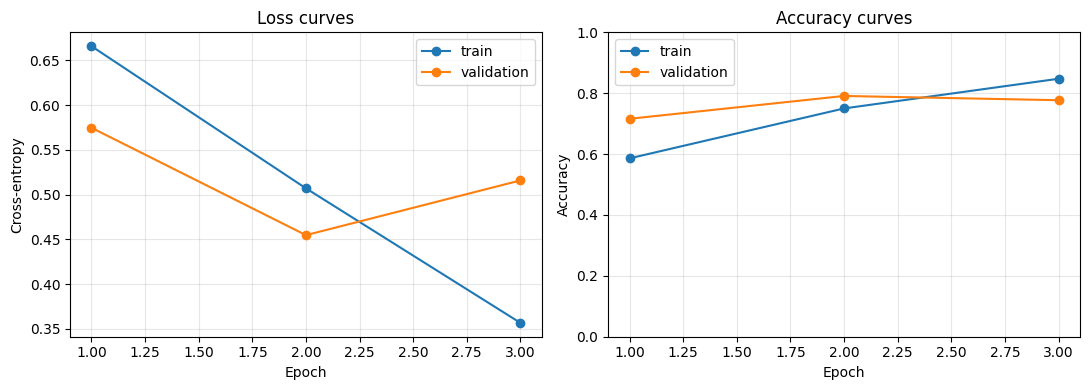

In [6]:
epochs = range(1, CONFIG["epochs"] + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="validation")
axes[0].set(title="Loss curves", xlabel="Epoch", ylabel="Cross-entropy"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(epochs, history["train_accuracy"], marker="o", label="train")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy curves", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1)); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 13–15. Test metrics, confusion matrix, and sample predictions

,value
accuracy,0.772000
precision,0.744361
recall,0.811475
f1_score,0.776471
test_samples,1000.000000


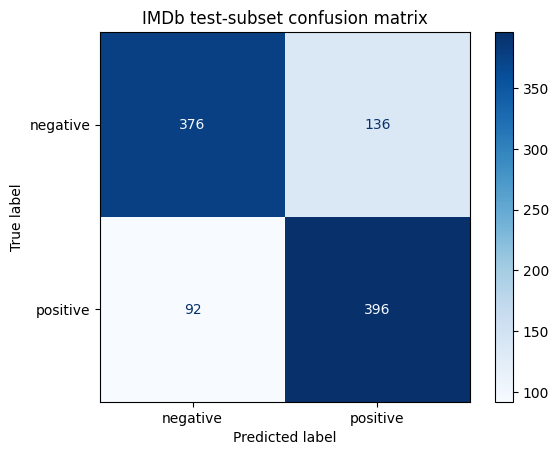

In [7]:
model.eval()
y_true, y_pred, probabilities, raw_texts = [], [], [], []
with torch.no_grad():
    for token_ids, _, labels, texts in test_loader:
        logits, _ = model(token_ids.to(DEVICE))
        probs = torch.softmax(logits, 1)[:, 1].cpu()
        y_true.extend(labels.tolist()); y_pred.extend((probs >= .5).long().tolist())
        probabilities.extend(probs.tolist()); raw_texts.extend(texts)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
results = pd.Series({"accuracy": accuracy_score(y_true, y_pred), "precision": precision,
                     "recall": recall, "f1_score": f1, "test_samples": len(y_true)})
display(results.to_frame("value"))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=["negative", "positive"]).plot(cmap="Blues")
plt.title("IMDb test-subset confusion matrix"); plt.show()

In [8]:
prediction_frame = pd.DataFrame({"text": raw_texts, "actual": y_true, "predicted": y_pred, "p_positive": probabilities})
for desired in [0, 1]:
    candidates = prediction_frame[(prediction_frame.predicted == desired) & (prediction_frame.actual == desired)]
    row = candidates.sort_values("p_positive", ascending=(desired == 0)).iloc[0]
    print(f"\nExample predicted {'POSITIVE' if desired else 'NEGATIVE'} (p={row.p_positive:.3f})")
    print("Actual:", "positive" if row.actual else "negative")
    print(row.text[:500].replace("<br />", " "))


Example predicted NEGATIVE (p=0.001)
Actual: negative
First, This movie was made in 1978. So that tells you that the movie is going to be bad anyway.But I am not saying that all old movies are bad . Second, The special effects we're terrible for even that time. Finally, The acting was so bad, Bozo The Clown could have done it better. It makes you wonder how people get the money to make movies this pathetic. This movie sucks!

Example predicted POSITIVE (p=0.999)
Actual: positive
Its the best movie I have seen in 2000, it has the beautiful and talented Natalie Portman in it. It has a great storyline, cast and soundtrack. I enjoyed it very much. 10 out of 10


## 16–17. Results and conclusion

The tables and plots above are produced from the executed model, not hard-coded values. The experiment demonstrates that a bidirectional LSTM can compress local and long-range review context while learned attention assigns different importance to individual time steps. Remaining errors can arise from truncation, rare words, sarcasm, and the deliberately small training subset. Larger subsets, pretrained embeddings, or more epochs are natural extensions.